In [3]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import savefig



In [2]:
df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/clean_merged_df_new.csv")


In [3]:
df_copy = df


In [41]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),region,region_num
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6
...,...,...,...,...,...,...,...,...,...,...,...,...
5937,ZWE,2018,7.549714,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,Sub-Sahara Africa,6
5938,ZWE,2019,7.469098,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,Sub-Sahara Africa,6
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6
5940,ZWE,2021,7.430857,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,Sub-Sahara Africa,6


In [4]:
df_copy = df_copy.drop_duplicates(subset=['country', 'year'])



In [5]:
gov_exp_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/gov_exp_df.csv")

# Merge Gov Exp into main df
df_copy = df_copy.merge(
    gov_exp_df[['country','year','General government final consumption expenditure (% of GDP)']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)
import numpy as np

# Replace ".." with NaN
df_copy['General government final consumption expenditure (% of GDP)'] = (
    df_copy['General government final consumption expenditure (% of GDP)']
    .replace('..', np.nan)
)

# Ensure the column is numeric
df_copy['General government final consumption expenditure (% of GDP)'] = pd.to_numeric(
    df_copy['General government final consumption expenditure (% of GDP)'],
    errors='coerce'
)

In [6]:
df_copy['log_gdppc'] = np.log(df_copy['gdppc'])


In [7]:
required_vars = [
    # 'Mortality rate, infant (per 1,000 live births)',
    "log_gdppc",
    'fe_etfra',
    'gdppc',
    'v2x_regime',
    'Population growth rate - Sex: all - Age: all - Variant: estimates',
    'export_share',
    'Gross capital formation (% of GDP)',
    #'hc',
    # 'Tax revenue (% of GDP)',
    'General government final consumption expenditure (% of GDP)',
    #'rtfpna',

]


def trim_country_panel(df_copy, country_col='country', year_col='year', vars_required=None):
    trimmed_dfs = []

    for country, g in df_copy.groupby(country_col):
        g = g.sort_values(year_col)

        # Rows where ALL required variables are present
        valid = g[vars_required].notna().all(axis=1)

        # If no fully valid rows → drop country
        if not valid.any():
            continue

        # First and last year with full data
        first_year = g.loc[valid, year_col].min()
        last_year = g.loc[valid, year_col].max()

        # Keep only that window
        g_trimmed = g[
            (g[year_col] >= first_year) &
            (g[year_col] <= last_year)
            ]

        # 🔑 THIS LINE enforces variable droppingrequired_vars
        g_trimmed = g_trimmed[[country_col, year_col] + vars_required]

        trimmed_dfs.append(g_trimmed)

    return pd.concat(trimmed_dfs, ignore_index=True)


df_copy = trim_country_panel(
    df_copy,
    country_col='country',
    year_col='year',
    vars_required=required_vars
)

In [8]:
len(df_copy)

5942

In [9]:
# Identify the Regions

# WESTERN EUROPE
WE = [
    "AUT","BEL","CHE","DEU","DNK","ESP","FIN","FRA","GBR","GRC",
    "IRL","ITA","LUX","NLD","NOR","PRT","SWE","ISL","AND","LIE",
    "MCO","SMR","VAT","MLT","CYP"
]

# EASTERN EUROPE
EE = [
    "ALB","ARM","AZE","BGR","BIH","BLR","CZE","EST","HRV","HUN",
    "LTU","LVA","MDA","MKD","MNE","POL","ROU","RUS","SRB",
    "SVK","SVN","UKR","XKX", "GEO"
]

# WESTERN OFFSHOOTS
WO = [
    "USA","CAN","AUS","NZL"
]

# LATIN AMERICA (incl. Caribbean & Central America)
LATAM = [
    "ARG","BOL","BRA","CHL","COL","CRI","CUB","DOM","ECU","GTM",
    "HND","HTI","JAM","MEX","NIC","PAN","PER","PRY","SLV","URY","VEN",
    "BHS","BRB","BLZ","GRD","GUY","SUR","TTO","ATG","DMA","KNA",
    "LCA","VCT","PRI","ABW","AIA","BMU","CUW","CYM","GLP","MTQ",
    "MSR","SPM","SXM","TCA","VGB","VIR"
]

# ASIA (EAST)
EASIA = [
    "CHN","JPN","KOR","MNG","HKG","MAC","TWN","PRK"
]

# ASIA (SOUTH & SOUTH-EAST) incl. Central Asia
SSEA = [
    "AFG","BGD","BTN","IDN","IND","KAZ","KGZ","KHM","LAO","LKA",
    "MMR","MYS","NPL","PAK","PHL","SGP","THA","TJK","TKM",
    "TLS","UZB","VNM","BRN"
]

# MIDDLE EAST (incl. North Africa & Turkey)
ME = [
    "ARE","BHR","DZA","EGY","ESH","IRN","IRQ","ISR","JOR","KWT",
    "LBN","LBY","MAR","OMN","QAT","SAU","SDN","SYR","TUN","TUR",
    "YEM","PSE"
]

# SUB-SAHARAN AFRICA
SSA = [
    "AGO","BDI","BEN","BFA","BWA","CAF","CIV","CMR","COD","COG",
    "COM","CPV","DJI","ERI","ETH","GAB","GHA","GIN","GMB","GNB",
    "GNQ","KEN","LBR","LSO","MDG","MLI","MOZ","MRT","MUS","MWI",
    "NAM","NER","NGA","RWA","SEN","SLE","SOM","SSD","STP","SWZ",
    "TCD","TGO","TZA","UGA","ZAF","ZMB","ZWE"
]


In [10]:
# Coding the Regions

region_map = {}

for c in WE:
    region_map[c] = "Western Europe"
for c in EE:
    region_map[c] = "Eastern Europe"
for c in WO:
    region_map[c] = "Western Offshoots"
for c in LATAM:
    region_map[c] = "Latin America"
for c in EASIA:
    region_map[c] = "Asia (East)"
for c in SSEA:
    region_map[c] = "Asia (South and South-East)"
for c in ME:
    region_map[c] = "Middle East"
for c in SSA:
    region_map[c] = "Sub-Sahara Africa"

df_copy["region"] = df_copy["country"].map(region_map)

In [154]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,population growth rate - sex: all - age: all - variant: estimates,export_share,gross capital formation (% of gdp),general government final consumption expenditure (% of gdp),region,region_num,transition,transition_year_dummy,binary_democracy
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2,1,1,0
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2,0,0,0
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2,1,1,0
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6,1,1,0
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5933,ZWE,2014,7.489415,0.366200,1789.004773,1.0,1.333,0.344570,9.639589,19.559868,Sub-Sahara Africa,6,0,0,0
5935,ZWE,2016,7.485957,0.366200,1782.830125,1.0,1.429,0.349474,9.861741,18.124445,Sub-Sahara Africa,6,0,0,0
5936,ZWE,2017,7.519663,0.366200,1843.946230,1.0,1.457,0.305773,14.702243,11.651490,Sub-Sahara Africa,6,0,0,0
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6,0,0,0


In [158]:
# Create Binary Democracy Variable

import numpy as np

df_copy["binary_democracy"] = np.where(
    df_copy["v2x_regime"].isin([0, 1]), 0,
    np.where(df_copy["v2x_regime"].isin([2, 3]), 1, np.nan)
)

df_copy["binary_democracy"] = df_copy["binary_democracy"].astype(int)



In [12]:
# Applying numbers to regions for analysis

region_to_num = {
    "Western Europe": 7,
    "Eastern Europe": 3,
    "Western Offshoots": 8,
    "Latin America": 4,
    "Asia (East)": 1,
    "Asia (South and South-East)": 2,
    "Middle East": 5,
    "Sub-Sahara Africa": 6
}

df_copy["region_num"] = df_copy["region"].map(region_to_num)

In [52]:
df_copy.to_csv("df_copy.csv", index=False)

In [31]:

tax_rev_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/tax_rev_df.csv")

# Merge tax revenue into main df
df_copy = df_copy.merge(
    tax_rev_df[['country','year','Tax revenue (% of GDP)']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)

In [32]:
# Replace ".." with NaN
df_copy['Tax revenue (% of GDP)'] = (
    df_copy['Tax revenue (% of GDP)']
    .replace('..', np.nan)
)

# Ensure the column is numeric
df_copy['Tax revenue (% of GDP)'] = pd.to_numeric(
    df_copy['Tax revenue (% of GDP)'],
    errors='coerce'
)

In [337]:
df_copy['log_gdppc'] = np.log(df_copy['gdppc'])

In [13]:
len(df_copy)

5942

In [14]:
df_copy["region"].unique()

array(['Asia (South and South-East)', 'Sub-Sahara Africa',
       'Eastern Europe', 'Middle East', 'Latin America',
       'Western Offshoots', 'Western Europe', 'Asia (East)'], dtype=object)

In [4]:
df_copy = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/df_copy.csv")


In [17]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),region,region_num,dem_binary,binary_democracy
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2,1,0
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2,1,0
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2,0,0
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6,0,0
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5937,ZWE,2018,7.549714,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,Sub-Sahara Africa,6,1,0
5938,ZWE,2019,7.469098,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,Sub-Sahara Africa,6,1,0
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6,1,0
5940,ZWE,2021,7.430857,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,Sub-Sahara Africa,6,1,0


In [5]:
len(df_copy)

5942

In [6]:
# MCF ANALYSIS - Training Testing Split -

def hybrid_country_split(df_copy, min_test_years=10):
    train_list = []
    test_list = []

    for country, g in df_copy.groupby("country"):
        g = g.sort_values("year")

        # If too short, keep all in training
        if len(g) <= min_test_years:
            train_list.append(g)
            continue

        # Check if democracy varies
        if g["v2x_regime"].nunique() > 1:
            # Keep last min_test_years for testing
            train_list.append(g.iloc[:-min_test_years])
            test_list.append(g.iloc[-min_test_years:])
        else:
            # No variation → random split within country
            train = g.sample(frac=0.7, random_state=42)
            test = g.drop(train.index)
            train_list.append(train)
            test_list.append(test)

    return pd.concat(train_list), pd.concat(test_list)

In [86]:
def mcf_safe_country_split(df_copy, min_train_years_after_transition=5, min_test_years=5):
    """
    Ensures:
    - Training set contains treatment variation (pre + post transition)
    - Test set contains only later years (no leakage)
    - Works for multi-valued treatments (0–3)
    """

    train_list = []
    test_list = []

    for country, g in df_copy.groupby("country"):
        g = g.sort_values("year")

        # If no variation → keep all in training (MCF cannot learn TE anyway)
        if g["v2x_regime"].nunique() == 1:
            train_list.append(g)
            continue

        # Identify first year where treatment changes
        transition_years = g.loc[g["v2x_regime"].diff() != 0, "year"]

        if len(transition_years) == 0:
            # Should not happen, but safe fallback
            train_list.append(g)
            continue

        first_transition = transition_years.min()

        # Define split point: ensure training includes variation
        split_year = first_transition + min_train_years_after_transition

        # Training = all years up to split_year
        train = g[g["year"] <= split_year]

        # Testing = later years, but ensure minimum size
        test = g[g["year"] > split_year]

        # If test set too small, keep all in training
        if len(test) < min_test_years:
            train_list.append(g)
        else:
            train_list.append(train)
            test_list.append(test)

    return pd.concat(train_list), pd.concat(test_list)


In [91]:
def panel_random_split(df_copy, train_frac=0.7, seed=42):
    """
    Performs a 70/30 split within each country.
    Ensures:
    - No country is entirely in train or test
    - Treatment variation is preserved
    - No leakage across countries
    """
    train_list = []
    test_list = []

    for country, g in df_copy.groupby("country"):
        g = g.sample(frac=1, random_state=seed)  # shuffle within country

        n_train = int(len(g) * train_frac)

        train_list.append(g.iloc[:n_train])
        test_list.append(g.iloc[n_train:])

    train_df = pd.concat(train_list).sort_values(["country", "year"])
    test_df = pd.concat(test_list).sort_values(["country", "year"])

    return train_df, test_df


In [98]:
from sklearn.model_selection import train_test_split

training_df, prediction_df = train_test_split(
    df_copy,
    test_size=0.30,
    random_state=42,
    shuffle=True
)


In [26]:
training_df, prediction_df = hybrid_country_split(df_copy)


In [34]:
# Import matplotlib
import matplotlib.pyplot as plt

In [35]:
#************************************#
# Start MCF analysis                 #
#************************************#
from mcf.mcf_main import ModifiedCausalForest

my_mcf = ModifiedCausalForest(
    var_y_name="log_gdppc",  # Outcome variable
    var_d_name="binary_democracy",    # Treatment variable
   # var_x_name_ord=[ "fe_etfra", "Population growth rate - Sex: all - Age: all - Variant: estimates", "export_share", "Mortality rate, infant (per 1,000 live births)", "Gross capital formation (% of GDP)",
                    # "hc", "General government final consumption expenditure (% of GDP)"],
   # var_x_name_ord=[ "fe_etfra", "export_share", "Gross capital formation (% of GDP)", "General government final consumption expenditure (% of GDP)", "Population growth rate - Sex: all - Age: all - Variant: estimates" ],
     var_x_name_ord=[ "fe_etfra", "export_share",  "Population growth rate - Sex: all - Age: all - Variant: estimates", "Gross capital formation (% of GDP)", "General government final consumption expenditure (% of GDP)" ],
    #var_x_name_ord=[ "fe_etfra", "Population growth rate - Sex: all - Age: all - Variant: estimates", "export_share"],
    #var_x_name_unord=["x_unord0"],  # Unordered covariate
    cs_max_del_train= 0.75,
    var_z_name_unord=["region_num"],
    p_bgate=True,
    p_se_boot_gate=500,   # e.g. 500 bootstrap draws
    p_ci_level=0.95,

     # Disable plots for faster performance
)
# Save all open figures as PNGs
for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    fig.savefig(f"mcf_plot_{i}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output0 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output1 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output2 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output3 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output4 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output5 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output6 already exists A new direct

In [37]:
# Train the Modified Causal Forest on the training data
my_mcf.train(training_df)

# Predict treatment effects using the model on prediction data
results = my_mcf.predict(prediction_df)

Modified Causal Forest: Training 
----------------------------------------------------------------------------------------------------

int_dict 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
iv :   False
cuda :   False
cython :   False
del_forest :   False
keep_w0 :   False
descriptive_stats :   True
dpi :   500
fontsize :   x-small
all_fonts :   xx-small x-small small medium large x-large xx-large
legend_loc :   best
no_filled_plot :   20
mp_ray_del :   refs
mp_ray_objstore_multiplier :   1
no_ray_in_forest_building :   False
mp_weights_tree_batch :   0
share_forest_sample :   0.5
weight_as_sparse :   True
show_plots :   True
report :   True
with_output :   True
verbose :   True
max_save_values :   50
mp_weights_type :   1
return_iate_sp :   True
seed_sample_split :   67567885
smaller_sample :   None
weight_as_sparse_splits :   1
mp_ray_shutdown :   False
mp_vim_type :   1
max_cats_cont_vars :   100004475
output_no_new_dir :   Fa

KeyError: 'region_num_prime'

In [279]:
# Access the Average Treatment Effect (ATE)
ate_array = results.get('ate')
print("Average Treatment Effect (ATE):\n", ate_array)


ate_se = results.get("ate_se")
print("ATE standard errors:\n", ate_se)

Average Treatment Effect (ATE):
 [[[0.23651939]]]
ATE standard errors:
 [[[0.02791837]]]


In [246]:
# Access GATEs directly from the results
gate_estimates = results['gate']
gate_se = results['gate_se']

print("GATE estimates:\n", gate_estimates)
print("\nGATE standard errors:\n", gate_se)

GATE estimates:
 [array([[[[0.36382684]]],


       [[[0.07444685]]],


       [[[0.28927531]]],


       [[[0.23046089]]],


       [[[0.25172233]]],


       [[[0.2517452 ]]],


       [[[0.45517859]]],


       [[[0.50801687]]]])]

GATE standard errors:
 [array([[[[0.07688229]]],


       [[[0.05013623]]],


       [[[0.05166228]]],


       [[[0.03066856]]],


       [[[0.05227956]]],


       [[[0.03998602]]],


       [[[0.09865786]]],


       [[[0.09597581]]]])]


In [22]:
# Access the Individualized Treatment Effects (IATE)
iate_array = results.get('iate')
print("\nIndividualized Treatment Effects (IATE):\n", iate_array)


Individualized Treatment Effects (IATE):
 [[[[-8.40675522e-002  1.03753786e-321]
   [ 1.53529359e-001  6.47225996e-322]
   [ 4.14683683e-001  1.11658836e-321]
   [ 2.37596911e-001  9.88131292e-323]
   [ 4.98751235e-001              nan]
   [ 2.61154324e-001  4.49599738e-322]]]


 [[[-9.79377207e-002  1.43279037e-321]
   [ 1.49611041e-001  6.47225996e-322]
   [ 4.07880213e-001  6.47225996e-322]
   [ 2.47548761e-001  3.45845952e-322]
   [ 5.05817934e-001              nan]
   [ 2.58269173e-001              nan]]]


 [[[-9.08360870e-002  1.03753786e-321]
   [ 1.55285642e-001  6.47225996e-322]
   [ 4.14436210e-001  1.11658836e-321]
   [ 2.46121729e-001  9.88131292e-323]
   [ 5.05272297e-001              nan]
   [ 2.59150568e-001  4.49599738e-322]]]


 ...


 [[[-2.34200811e-001  1.03753786e-321]
   [ 5.57211487e-002  6.47225996e-322]
   [ 5.27417190e-001  1.11658836e-321]
   [ 2.89921960e-001  9.88131292e-323]
   [ 7.61618001e-001              nan]
   [ 4.71696041e-001  4.49599738e-322]]]


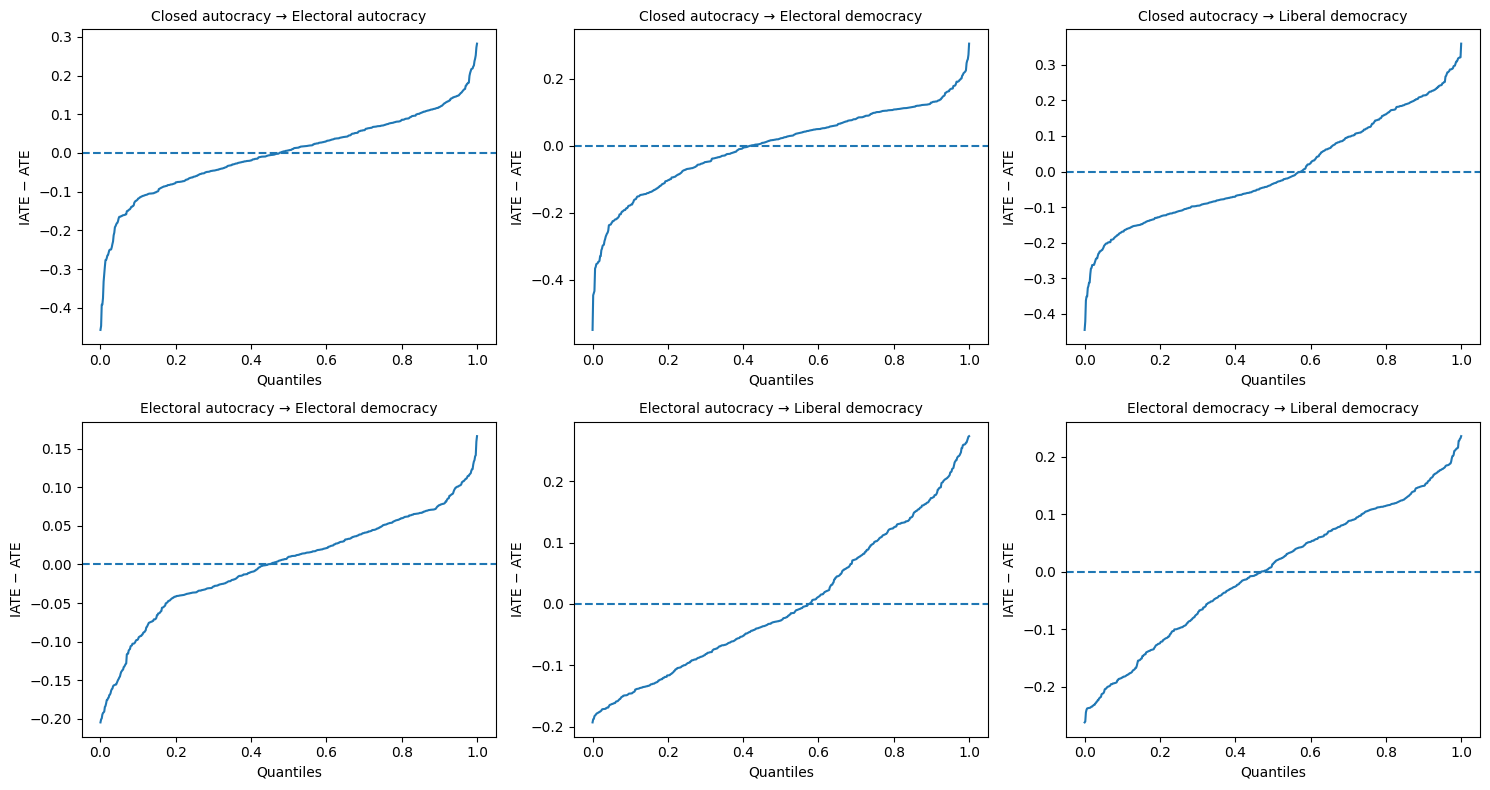

In [42]:
#IATES GRAPHS

import numpy as np
import matplotlib.pyplot as plt

iate = results.get('iate')

regime_labels = [
"Closed autocracy → Electoral autocracy",
"Closed autocracy → Electoral democracy",
"Closed autocracy → Liberal democracy",
"Electoral autocracy → Electoral democracy",
"Electoral autocracy → Liberal democracy",
"Electoral democracy → Liberal democracy"
]

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for k in range(6):

    # Extract IATE values
    iate_values = iate[:,0,k,0]

    # remove NaN
    iate_values = iate_values[~np.isnan(iate_values)]

    # compute ATE
    ate = np.mean(iate_values)

    # IATE deviation from ATE
    diff = iate_values - ate

    # sort
    sorted_diff = np.sort(diff)

    # quantiles
    quantiles = np.linspace(0,1,len(sorted_diff))

    ax = axes[k]

    ax.plot(quantiles, sorted_diff)
    ax.axhline(0, linestyle='--')

    ax.set_title(regime_labels[k], fontsize=10)
    ax.set_xlabel("Quantiles")
    ax.set_ylabel("IATE − ATE")

plt.tight_layout()
plt.savefig("IATEs-ATE.png", dpi=300, bbox_inches='tight')
plt.show()


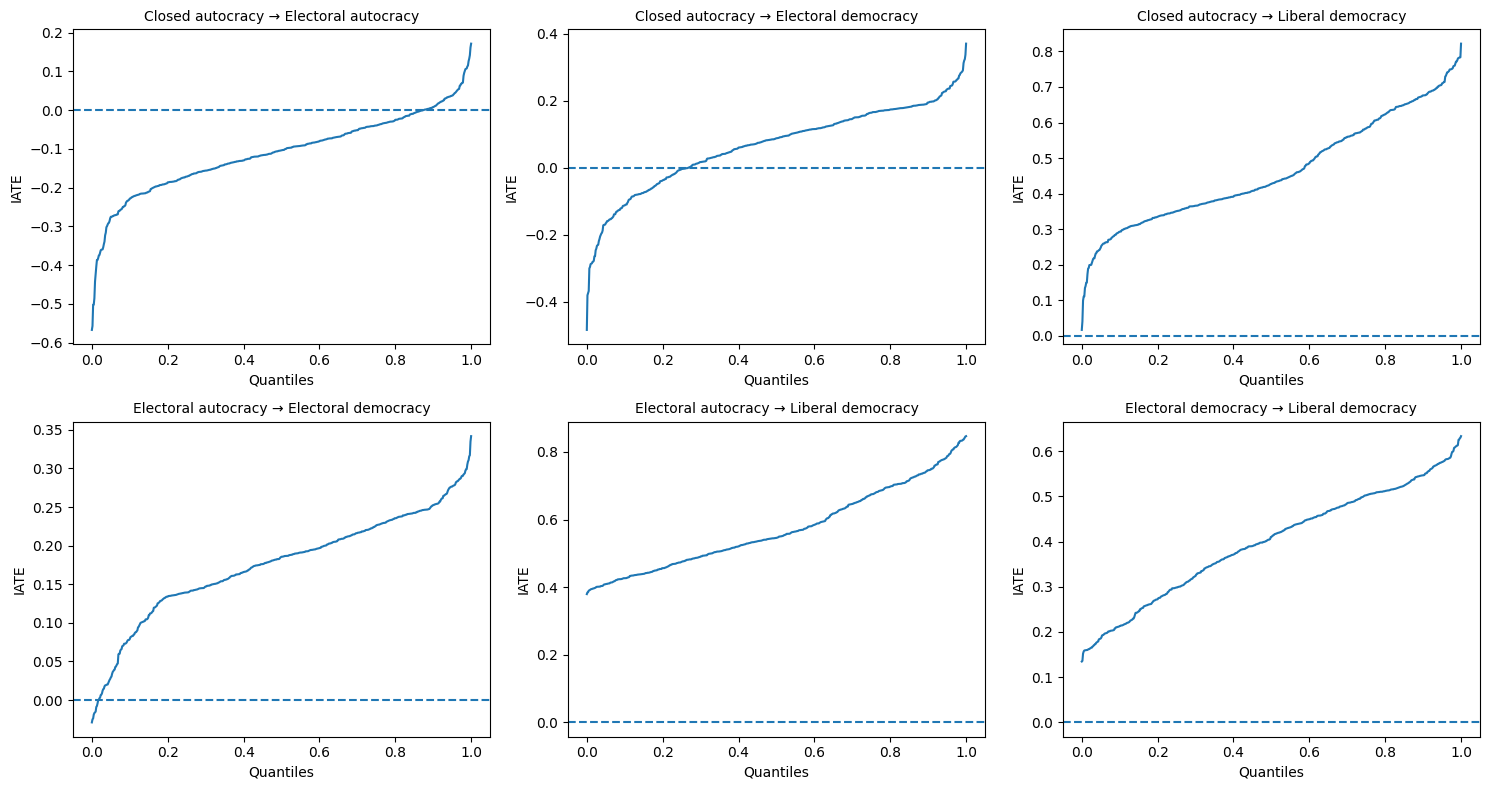

In [43]:
# IATES GRAPHS (direct IATEs)

import numpy as np
import matplotlib.pyplot as plt

iate = results.get('iate')

regime_labels = [
"Closed autocracy → Electoral autocracy",
"Closed autocracy → Electoral democracy",
"Closed autocracy → Liberal democracy",
"Electoral autocracy → Electoral democracy",
"Electoral autocracy → Liberal democracy",
"Electoral democracy → Liberal democracy"
]

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for k in range(6):

    # Extract IATE values
    iate_values = iate[:,0,k,0]

    # remove NaN
    iate_values = iate_values[~np.isnan(iate_values)]

    # sort IATEs directly
    sorted_iate = np.sort(iate_values)

    # quantiles
    quantiles = np.linspace(0,1,len(sorted_iate))

    ax = axes[k]

    ax.plot(quantiles, sorted_iate)
    ax.axhline(0, linestyle='--')

    ax.set_title(regime_labels[k], fontsize=10)
    ax.set_xlabel("Quantiles")
    ax.set_ylabel("IATE")

plt.tight_layout()
plt.savefig("IATEs.png", dpi=300, bbox_inches='tight')
plt.show()

In [265]:
# WALD tests for ATEs not regions but pairwise comparisosn

import numpy as np
import pandas as pd
from scipy.stats import chi2

# ================================
# 1. Load your ATE results
# ================================
ate = np.array(results.get('ate')).flatten()
se = np.array(results.get('ate_se')).flatten()

# Optional: print to verify
print("ATE:", ate)
print("SE:", se)

# ================================
# 2. Define labels (IMPORTANT)
# ================================
labels = [
    "Electoral autocracy - Closed autocracy",
    "Electoral democracy - Closed autocracy",
    "Liberal democracy - Closed autocracy",
    "Electoral democracy - Electoral autocracy",
    "Liberal democracy - Electoral autocracy",
    "Liberal democracy - Electoral democracy"
]

# ================================
# 3. Wald test function
# ================================
def wald_test(theta, se, indices):
    theta_sub = theta[indices]
    se_sub = se[indices]

    V = np.diag(se_sub**2)  # covariance (independence assumption)
    k = len(indices)

    # Restriction: all coefficients equal
    R = np.eye(k) - (1/k)
    R = R[:-1]  # avoid singularity

    W = theta_sub.T @ R.T @ np.linalg.inv(R @ V @ R.T) @ R @ theta_sub
    df = R.shape[0]
    p_value = 1 - chi2.cdf(W, df)

    return W, df, p_value

# ================================
# 4. Define groups (LIKE LECHNER STYLE)
# ================================
tests = {
    "Closed autocracy transitions (0,1,2)": [0,1,2],
    "Electoral autocracy transitions (3,4)": [3,4],
    "All transitions (0-5)": [0,1,2,3,4,5],
   #"Upgrading transitions (1,2,3,4,5)": [1,2,3,4,5]
}

# ================================
# 5. Run all Wald tests
# ================================
results_list = []

for name, idx in tests.items():

    if len(idx) == 1:
        # Single coefficient → no Wald test possible
        results_list.append([name, np.nan, 0, np.nan])
        continue

    W, df, p = wald_test(ate, se, idx)

    results_list.append([name, W, df, p * 100])  # p in %

# ================================
# 6. Create final table
# ================================
wald_table = pd.DataFrame(results_list, columns=[
    "Comparison",
    "Chi2",
    "df",
    "p-value (%)"
])

# Round nicely
wald_table = wald_table.round(3)

print("\nWald Test Results:\n")
print(wald_table)

# ================================
# 7. OPTIONAL: Save table
# ================================
wald_table.to_csv("wald_tests_ate.csv", index=False)
savefig(
    "wald_tests_ate.csv", )



ATE: [-0.11589378  0.0627899   0.45635305  0.17868367  0.57224683  0.39356315]
SE: [0.05288919 0.0516914  0.05626698 0.03925514 0.04511029 0.04369981]

Wald Test Results:

                              Comparison     Chi2  df  p-value (%)
0   Closed autocracy transitions (0,1,2)   56.852   2          0.0
1  Electoral autocracy transitions (3,4)   43.315   1          0.0
2                  All transitions (0-5)  138.569   5          0.0


NameError: name 'savefig' is not defined

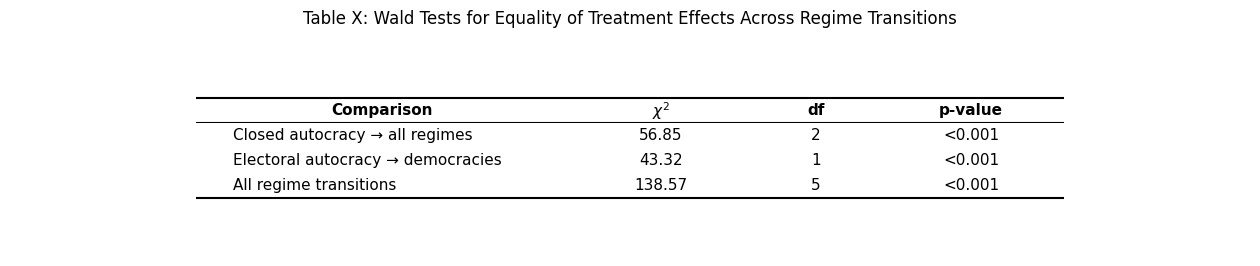

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ================================
# 1. Load your data
# ================================
ate = np.array(results.get('ate')).flatten()
se = np.array(results.get('ate_se')).flatten()

# ================================
# 2. Wald test function
# ================================
def wald_test(theta, se, indices):
    theta_sub = theta[indices]
    se_sub = se[indices]

    V = np.diag(se_sub**2)
    k = len(indices)

    R = np.eye(k) - (1/k)
    R = R[:-1]

    W = theta_sub.T @ R.T @ np.linalg.inv(R @ V @ R.T) @ R @ theta_sub
    df = R.shape[0]
    p_value = 1 - chi2.cdf(W, df)

    return W, df, p_value

# ================================
# 3. Define meaningful tests
# ================================
tests = {
    "Closed autocracy → all regimes": [0,1,2],
    "Electoral autocracy → democracies": [3,4],
    "All regime transitions": [0,1,2,3,4,5]
}

# ================================
# 4. Run tests
# ================================
rows = []

for name, idx in tests.items():
    W, df, p = wald_test(ate, se, idx)

    rows.append([
        name,
        f"{W:.2f}",
        df,
        "<0.001" if p < 0.001 else f"{p:.3f}"
    ])

wald_table = pd.DataFrame(rows, columns=[
    "Comparison",
    r"$\chi^2$",
    "df",
    "p-value"
])

# ================================
# 5. Create journal-style figure
# ================================
fig, ax = plt.subplots(figsize=(16, 2.8))
ax.axis('off')

table = ax.table(
    cellText=wald_table.values,
    colLabels=wald_table.columns,
    cellLoc='center',
    loc='center'
)

# Set custom column widths (must sum roughly to 1)
col_widths = [0.3, 0.15, 0.1, 0.15]

for i, width in enumerate(col_widths):
    for j in range(len(wald_table) + 1):  # +1 for header
        table[j, i].set_width(width)

# ================================
# 6. Styling (IMPORTANT)
# ================================
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# Header style
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_linewidth(1.5)
    else:
        cell.set_linewidth(0.8)

# Left align first column (like papers)
for i in range(1, len(wald_table) + 1):
    table[i, 0].get_text().set_ha('left')

# Title
plt.title("Table X: Wald Tests for Equality of Treatment Effects Across Regime Transitions",
          fontsize=12, pad=12)

# Remove all borders first
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0)

# Get dimensions
n_rows = len(wald_table) + 1  # +1 header
n_cols = len(wald_table.columns)

# Add top border + header bottom border
for col in range(n_cols):
    # Top border (header top)
    table[0, col].visible_edges = 'T'
    table[0, col].set_linewidth(1.5)

    # Header bottom line
    table[0, col].visible_edges += 'B'

# Add bottom border (last row)
for col in range(n_cols):
    table[n_rows - 1, col].visible_edges = 'B'
    table[n_rows - 1, col].set_linewidth(1.5)


# ================================
# 7. Save as figure
# ================================
plt.savefig("wald_tests_table.png", dpi=300, bbox_inches='tight')
plt.savefig("wald_tests_table.pdf", bbox_inches='tight')

plt.show()


In [23]:
# WALD tests for GATEs 8 regions
gate = results.get("gate")              # GATE estimates
gate_se = results.get("gate_se")        # Standard errors
gate_groups = results.get("gate_feature_values")  # Group labels (region_num)



gate_estimates = results['gate']
gate_se = results['gate_se']

import numpy as np
from scipy.stats import chi2

# Convert to numpy arrays (important!)
theta = np.array(gate_estimates).flatten()
se = np.array(gate_se).flatten()

k = len(theta)

# Variance-covariance matrix (assuming independence)
V = np.diag(se**2)

# Restriction matrix: all coefficients equal
R = np.eye(k) - (1/k)
R = R[:-1]  # drop one row to avoid singularity

# Wald statistic
W = theta.T @ R.T @ np.linalg.inv(R @ V @ R.T) @ R @ theta

df = R.shape[0]
p_value = 1 - chi2.cdf(W, df)

print(f"Wald statistic: {W:.3f}")
print(f"Degrees of freedom: {df}")
print(f"p-value: {p_value:.5f}")


Wald statistic: 26.981
Degrees of freedom: 7
p-value: 0.00034


In [370]:
import numpy as np

gate_arr = np.asarray(gate[0]).reshape(-1)      # shape (num_groups,)
gate_se_arr = np.asarray(gate_se[0]).reshape(-1)
groups = np.asarray(gate_groups).reshape(-1)


In [372]:
results.get("d_values_dict")


In [377]:
results["gate_names_values"]


{'z_names_list': ['region_num'], 'region_num': [0, 1, 2, 3, 4, 5, 6, 7]}

In [380]:
print("len groups:", len(results["gate_names_values"]["region_num"]))
print("len gate:", len(results["gate"][0][0][0]))
print("len gate_se:", len(results["gate_se"][0][0][0]))


len groups: 8
len gate: 1
len gate_se: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose comparison
idx = 0   # 0 vs 1

# Extract GATE and SE
gate_arr = np.asarray(results["gate"][idx][0][0])
gate_se_arr = np.asarray(results["gate_se"][idx][0][0])

# Extract region groups
groups = np.array(results["gate_names_values"]["region_num"])

# Confidence intervals
ci_upper = gate_arr + 1.96 * gate_se_arr
ci_lower = gate_arr - 1.96 * gate_se_arr

# Plot
plt.errorbar(groups, gate_arr,
             yerr=[gate_arr - ci_lower, ci_upper - gate_arr],
             fmt='o', capsize=4)

plt.title(f"GATE for comparison {results['ate_effect_list'][idx]}")
plt.xlabel("region_num")
plt.ylabel("Effect")
plt.grid(True)
plt.show()


In [375]:
idx = 2   # because row 2 is 2 vs 3

gate_arr = np.asarray(results["gate"][idx][0][0])
gate_se_arr = np.asarray(results["gate_se"][idx][0][0])
groups = np.asarray(results["gate_names_values"][0])


IndexError: list index out of range

In [108]:
comparison_labels = [
    "Electoral autocracy – Closed autocracy",
    "Electoral democracy – Closed autocracy",
    "Liberal democracy – Closed autocracy",
    "Electoral democracy – Electoral autocracy",
    "Liberal democracy – Electoral autocracy",
    "Liberal democracy – Electoral democracy"
]



In [109]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Extract ATEs and SEs
ate = results.get("ate").flatten()
ate_se = results.get("ate_se").flatten()

# z-stats and p-values
z_stats = ate / ate_se
p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))

# Table
table = pd.DataFrame({
    "Comparison": comparison_labels,
    "Effect": ate,
    "Std. Error": ate_se,
    "p-value (%)": 100 * p_values
})

# Round for presentation
table = table.round({
    "Effect": 3,
    "Std. Error": 3,
    "p-value (%)": 1
})

table


,Comparison,Effect,Std. Error,p-value (%)
0,Electoral autocracy – Closed autocracy,-0.116,0.053,2.8
1,Electoral democracy – Closed autocracy,0.063,0.052,22.4
2,Liberal democracy – Closed autocracy,0.456,0.056,0.0
3,Electoral democracy – Electoral autocracy,0.179,0.039,0.0
4,Liberal democracy – Electoral autocracy,0.572,0.045,0.0
5,Liberal democracy – Electoral democracy,0.394,0.044,0.0


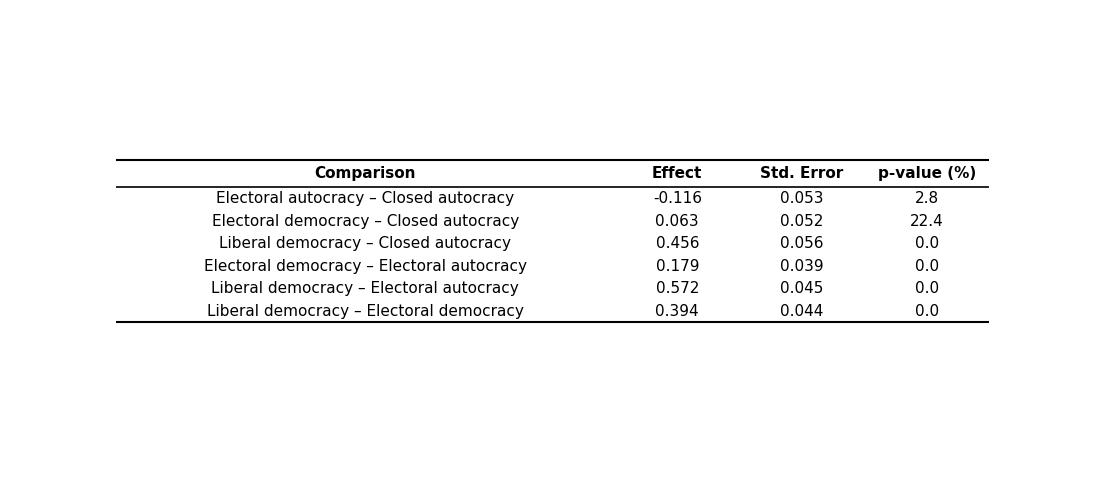

In [110]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
    colWidths=[0.40, 0.1, 0.1, 0.1]
)

# -----------------------------
# Font & scale (slightly tighter)
# -----------------------------
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.15, 1.35)   # ↓ vertical scale
#tbl.scale(0.85, 1)
# -----------------------------
# Remove all borders
# -----------------------------
for cell in tbl.get_celld().values():
    cell.set_linewidth(0)

# -----------------------------
# Dimensions
# -----------------------------
n_rows = len(table)
n_cols = len(table.columns)

# -----------------------------
# Compress header row height
# -----------------------------
for c in range(n_cols):
    header_cell = tbl[(0, c)]
    header_cell.set_height(0.06)   # ↓ tighter header spacing

# -----------------------------
# Top rule
# -----------------------------
for c in range(n_cols):
    cell = tbl[(0, c)]
    cell.visible_edges = "T"
    cell.set_linewidth(1.5)

# -----------------------------
# Double rule under header
# -----------------------------
for c in range(n_cols):
    cell = tbl[(1, c)]
    cell.visible_edges = "T"
    cell.set_linewidth(1.2)

# -----------------------------
# Bottom rule
# -----------------------------
for c in range(n_cols):
    cell = tbl[(n_rows, c)]
    cell.visible_edges = "B"
    cell.set_linewidth(1.5)

# -----------------------------
# Bold column headers
# -----------------------------
for c in range(n_cols):
    tbl[(0, c)].get_text().set_fontweight("bold")

# -----------------------------
# Save figure
# -----------------------------
plt.savefig(
    "MCF_ATE_logGDPpc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [247]:
# Access the Group Average Treatment Effect (GATE)

gate = results.get("gate")
gate_se = results.get("gate_se")

print("GATE:\n", gate)
print("GATE standard errors:\n", gate_se)


GATE:
 [array([[[[0.36382684]]],


       [[[0.07444685]]],


       [[[0.28927531]]],


       [[[0.23046089]]],


       [[[0.25172233]]],


       [[[0.2517452 ]]],


       [[[0.45517859]]],


       [[[0.50801687]]]])]
GATE standard errors:
 [array([[[[0.07688229]]],


       [[[0.05013623]]],


       [[[0.05166228]]],


       [[[0.03066856]]],


       [[[0.05227956]]],


       [[[0.03998602]]],


       [[[0.09865786]]],


       [[[0.09597581]]]])]


In [250]:
import numpy as np
import pandas as pd

# Extract GATE and SE arrays from results dictionary
gate_raw = results.get("gate")
gate_se_raw = results.get("gate_se")

# Convert to clean 2D arrays
gate_values = np.squeeze(np.array(gate_raw))
gate_se = np.squeeze(np.array(gate_se_raw))

# -----------------------------
# Flatten GATE arrays safely
# -----------------------------
# Extract the first element of the list (the actual array)
gate_array = np.array(gate_raw[0]).flatten()      # shape (8,)
gate_se_array = np.array(gate_se_raw[0]).flatten()  # shape (8,)

# -----------------------------
# Regions
# -----------------------------
regions = [
    'Asia (East)', 'Asia (South and South-East)', 'Eastern Europe', 'Latin America',
    'Middle East', 'Sub-Sahara Africa', 'Western Europe', 'Western Offshoots'
]


# -----------------------------
# Compute z-statistics and p-values
# -----------------------------
z_stats = gate_array / gate_se_array
p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))  # two-sided

# Convert to percentage
p_values_percent = 100 * p_values

# -----------------------------
# Build DataFrame
# -----------------------------
df_gates = pd.DataFrame({
    "Region": regions,
    "GATE": gate_array,
    "Std. Error": gate_se_array,
    "p-value (%)": p_values_percent
})

# Round nicely
df_gates = df_gates.round({
    "GATE": 3,
    "Std. Error": 3,
    "p-value (%)": 1
})

# -----------------------------
# Display
# -----------------------------
print(df_gates)


                        Region   GATE  Std. Error  p-value (%)
0                  Asia (East)  0.364       0.077          0.0
1  Asia (South and South-East)  0.074       0.050         13.8
2               Eastern Europe  0.289       0.052          0.0
3                Latin America  0.230       0.031          0.0
4                  Middle East  0.252       0.052          0.0
5            Sub-Sahara Africa  0.252       0.040          0.0
6               Western Europe  0.455       0.099          0.0
7            Western Offshoots  0.508       0.096          0.0


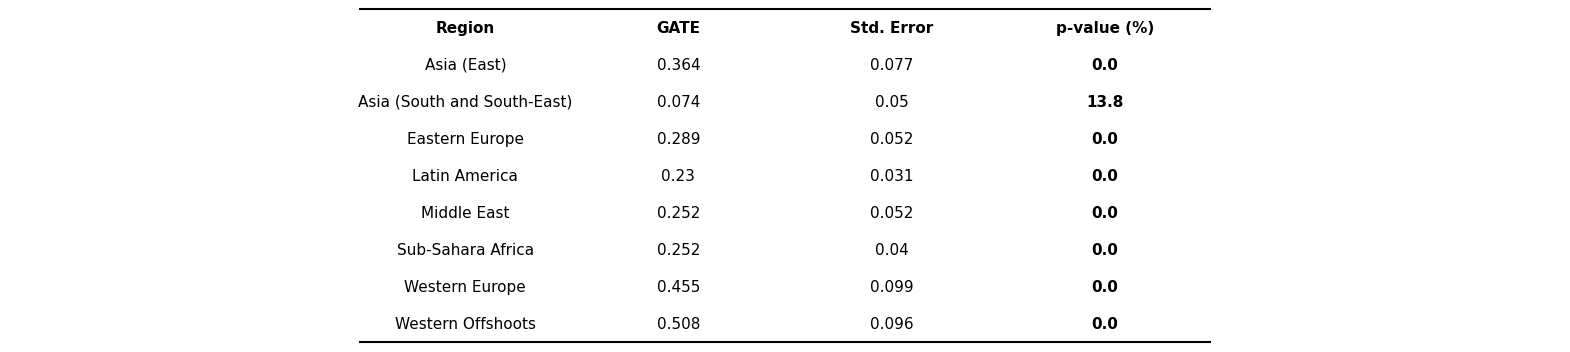

In [251]:
# -----------------------------
# Plot the table as PNG with desired style
# -----------------------------
fig, ax = plt.subplots(figsize=(20, 4))
ax.axis("off")

tbl = ax.table(
    cellText=df_gates.values,
    colLabels=df_gates.columns,
    cellLoc="center",
    loc="center"
)

# Remove all borders except top and bottom
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)

# Top border (header row)
for c in range(len(df_gates.columns)):
    tbl[(0, c)].visible_edges = "T"
    tbl[(0, c)].set_linewidth(1.5)

# Bottom border (last data row)
last_row = len(df_gates.index)
for c in range(len(df_gates.columns)):
    tbl[(last_row, c)].visible_edges = "B"
    tbl[(last_row, c)].set_linewidth(1.5)

# Font and scale
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(0.55, 1.3)   # width x height

# Bold column headers
for c in range(len(df_gates.columns)):
    tbl[(0, c)].get_text().set_fontweight("bold")
    tbl[(0, c)].set_height(0.06)
    tbl[(0, c)].visible_edges = "T"

# Bold last column cells (row labels)
last_col = len(df_gates.columns) - 1
for r in range(1, len(df_gates.index) + 1):
    tbl[(r, last_col)].get_text().set_fontweight("bold")

# Increase row heights manually
for (row, col), cell in tbl.get_celld().items():
    cell.set_height(0.12)

# Save figure
plt.savefig("gate_table_formatted.png", bbox_inches='tight', dpi=300)
plt.show()

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Region and transition labels
regions = [
    'Asia (East)', 'Asia (South and South-East)', 'Eastern Europe', 'Latin America',
    'Middle East', 'Sub-Sahara Africa', 'Western Europe', 'Western Offshoots'
]

transitions = [
    'Regime 1 → 2', 'Regime 1 → 3', 'Regime 1 → 4',
    'Regime 2 → 3', 'Regime 2 → 4', 'Regime 3 → 4'
]

# Extract GATE and SE arrays from results dictionary
gate_raw = results.get("gate")
gate_se_raw = results.get("gate_se")

# Convert to clean 2D arrays
gate_values = np.squeeze(np.array(gate_raw))
gate_se = np.squeeze(np.array(gate_se_raw))

# Format table cells: estimate + (standard error)
cell_text = []
for i in range(len(regions)):
    row = []
    for j in range(len(transitions)):
        est = round(gate_values[i, j], 3)
        se = round(gate_se[i, j], 3)
        row.append(f"{est}{stars(p)}\n({se})")
    cell_text.append(row)

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Create the table
table = ax.table(
    cellText=cell_text,
    rowLabels=regions,
    colLabels=transitions,
    loc='center',
    cellLoc='center',
    rowLoc='center'
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)

table.scale(1, 2.3)   # 1 = width, 1.6 = height multiplier


# Bold headers
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold')

# Save figure
plt.savefig("gate_table_auto.png", bbox_inches='tight', dpi=300)
plt.show()


NameError: name 'p' is not defined

In [255]:
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


In [256]:
from scipy.stats import norm

# Compute p-values
p_values = 2 * (1 - norm.cdf(np.abs(gate_values / gate_se)))


In [257]:
from scipy.stats import norm

# Compute p-values
p_values = 2 * (1 - norm.cdf(np.abs(gate_values / gate_se)))

# Build table text
cell_text = []
for i in range(len(regions)):
    row = []
    for j in range(len(transitions)):
        est = round(gate_values[i, j], 3)
        se = round(gate_se[i, j], 3)
        p = p_values[i, j]

        # significance stars
        if p < 0.01:
            star = "***"
        elif p < 0.05:
            star = "**"
        elif p < 0.10:
            star = "*"
        else:
            star = ""

        row.append(f"{est}{star}\n({se})")
    cell_text.append(row)

# Create table
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=regions,
    colLabels=transitions,
    loc='center',
    cellLoc='center'
)

# Increase row height
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.15)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 0.8)

plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ----------------------------------------------------
# 1. Region and transition labels
# ----------------------------------------------------
regions = [
    'Asia (East)', 'Asia (South and South-East)', 'Eastern Europe', 'Latin America',
    'Middle East', 'Sub-Sahara Africa', 'Western Europe', 'Western Offshoots'
]

transitions = [
    'Regime 1 → 2', 'Regime 1 → 3', 'Regime 1 → 4',
    'Regime 2 → 3', 'Regime 2 → 4', 'Regime 3 → 4'
]

# ----------------------------------------------------
# 2. Extract GATE and SE from results
# ----------------------------------------------------
gate_raw = results.get("gate")
gate_se_raw = results.get("gate_se")

gate_values = np.squeeze(np.array(gate_raw))
gate_se = np.squeeze(np.array(gate_se_raw))

# ----------------------------------------------------
# 3. Compute p-values and significance stars
# ----------------------------------------------------
p_values = 2 * (1 - norm.cdf(np.abs(gate_values / gate_se)))

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# ----------------------------------------------------
# 4. Build table text (estimate + stars + SE)
# ----------------------------------------------------
cell_text = []
for i in range(len(regions)):
    row = []
    for j in range(len(transitions)):
        est = round(gate_values[i, j], 3)
        se = round(gate_se[i, j], 3)
        p = p_values[i, j]
        row.append(f"{est}{stars(p)}\n({se})")
    cell_text.append(row)

# ----------------------------------------------------
# 5. Convert to pandas DataFrame for your styling block
# ----------------------------------------------------
import pandas as pd
table = pd.DataFrame(cell_text, index=regions, columns=transitions)

# ----------------------------------------------------
# 6. Plot as publication-style table (your style)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    rowLabels=table.index,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
    colWidths=[0.2, 0.2, 0.3, 0.2, 0.2, 0.2]
)

# ----------------------------------------------------
# Remove all borders except top and bottom
# ----------------------------------------------------
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)   # remove all borders

# Top border (header row)
for c in range(len(table.columns)):
    tbl[(0, c)].visible_edges = "T"
    tbl[(0, c)].set_linewidth(1.5)

# Bottom border (last data row)
last_row = len(table.index)
for c in range(len(table.columns)):
    tbl[(last_row, c)].visible_edges = "B"
    tbl[(last_row, c)].set_linewidth(1.5)



# Font and scale
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(0.7, 1.3)   # Increase row height

# Bold column headers
for c in range(len(table.columns)):
    tbl[(0, c)].get_text().set_fontweight("bold")
    tbl[(0, c)].set_height(0.06)
    tbl[(0, c)].visible_edges = "T"

# Bold row labels
for r in range(1, len(table.index) + 1):
    tbl[(r, -1)].get_text().set_fontweight("bold")

# Increase row heights manually
for (row, col), cell in tbl.get_celld().items():
    cell.set_height(0.12)

for c in range(len(table.columns)):
    tbl[(0, c)].visible_edges = "T"




# ----------------------------------------------------
# 7. Save figure
# ----------------------------------------------------
plt.savefig("GATE_transitions_table.png", dpi=300, bbox_inches="tight")
plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [165]:
p_values

array([[2.74246719e-01, 1.56593912e-02, 4.55370186e-10, 9.25023857e-02,
        1.10592335e-09, 1.39476359e-04],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [9.50403440e-01, 1.21460456e-01, 1.01140096e-09, 3.87268386e-02,
        0.00000000e+00, 2.59510191e-11],
       [4.35375498e-01, 7.61934345e-04, 0.00000000e+00, 5.27094188e-05,
        0.00000000e+00, 2.88657986e-15],
       [2.74739754e-01, 5.02692175e-01, 1.47712798e-09, 5.83093667e-02,
        2.88502555e-12, 1.11444187e-12],
       [8.77925812e-02, 8.92093853e-02, 8.39328607e-14, 6.84560996e-04,
        0.00000000e+00, 3.60076413e-11],
       [7.16685081e-01, 2.25470590e-01, 1.84707805e-11, 1.39365600e-01,
        8.32183211e-11, 1.02593007e-08],
       [5.15743675e-01, 2.09134756e-01, 7.04500458e-10, 5.49610476e-02,
        5.20330445e-11, 6.30317132e-09],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 

In [168]:
gate_raw = results["gate"]

type(gate_raw)
len(gate_raw)

import numpy as np

gate_arr = np.asarray(gate_raw[0])
print(gate_arr.shape)

gate_clean = gate_arr[:, 0, 0, :]

import pandas as pd

region_names = [
    "Asia (East)",
    "Asia (South and South-East)",
    "Eastern Europe",
    "Latin America",
    "Middle East",
    "Sub-Sahara Africa",
    "Western Europe",
    "Western Offshoots"
]

gate_df = pd.DataFrame(
    gate_clean,
    index=region_names,
    columns=[
        "Regime 1 → 2",
        "Regime 1 → 3",
        "Regime 1 → 4",
        "Regime 2 → 3",
        "Regime 2 → 4",
        "Regime 3 → 4"
    ]
)

gate_df

(8, 1, 1, 1)


ValueError: Shape of passed values is (8, 1), indices imply (8, 6)

In [85]:
from data_functions import load_maddison


In [86]:
maddisson_df = load_maddison()

In [94]:
maddisson_df["country"].nunique()

168

In [95]:
from data_functions import load_vdem

In [96]:
vdem_df = load_vdem()

In [98]:
vdem_df["country"].nunique()

182

In [222]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),region,region_num,dem_binary
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2,1
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2,1
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2,0
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6,0
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5937,ZWE,2018,7.549714,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,Sub-Sahara Africa,6,1
5938,ZWE,2019,7.469098,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,Sub-Sahara Africa,6,1
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6,1
5940,ZWE,2021,7.430857,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,Sub-Sahara Africa,6,1


In [14]:
import pandas as pd

# Create binary democracy indicator
df_copy["dem_binary"] = (df_copy["v2x_regime"] >= 1).astype(int)

# List of variables for descriptives
vars_desc = [
    "gdppc",
    "export_share",
    "fe_etfra",
    "Population growth rate - Sex: all - Age: all - Variant: estimates",
    "Gross capital formation (% of GDP)",
    "General government final consumption expenditure (% of GDP)"
]

# Descriptive statistics by democracy vs. non-democracy
desc_binary = df_copy.groupby("dem_binary")[vars_desc].describe()
desc_binary


gdppc                                                  \
             count          mean           std    min          25%   
dem_binary                                                           
0           1162.0  10054.900378  15046.596700  521.0  1706.750000   
1           4780.0  13772.565644  13475.313497  561.0  3233.023262   

                                                    export_share            \
                    50%           75%           max        count      mean   
dem_binary                                                                   
0           4928.000000   9856.338048  80657.134438       1146.0  0.442425   
1           9093.435844  20718.736804  88366.219328       4775.0  0.432887   

            ... Gross capital formation (% of GDP)             \
            ...                                75%        max   
dem_binary  ...                                                 
0           ...                          29.801351  70.229340   
1           ...                          27.157606  73.494646   

           General government final consumption expenditure (% of GDP)  \
                                                                 count   
dem_binary                                                               
0                                                      1147.0            
1                                                      4750.0            

                                                                            \
                 mean       std       min        25%        50%        75%   
dem_binary                                                                   
0           16.801139  8.012314  0.000000  11.091219  15.466102  20.196888   
1           15.359052  5.607231  2.047121  11.256284  14.989747  18.855583   

                       
                  max  
dem_binary             
0           76.222125  
1           55.099922  

[2 rows x 48 columns]

In [15]:
import numpy as np

df_copy["binary_democracy"] = np.where(
    df_copy["v2x_regime"].isin([0, 1]), 0,
    np.where(df_copy["v2x_regime"].isin([2, 3]), 1, np.nan)
)

df_copy["binary_democracy"] = df_copy["binary_democracy"].astype(int)


In [16]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),region,region_num,dem_binary,binary_democracy
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2,1,0
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2,1,0
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2,0,0
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6,0,0
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5937,ZWE,2018,7.549714,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,Sub-Sahara Africa,6,1,0
5938,ZWE,2019,7.469098,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,Sub-Sahara Africa,6,1,0
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6,1,0
5940,ZWE,2021,7.430857,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,Sub-Sahara Africa,6,1,0


In [101]:
df_copy.groupby("v2x_regime")[["gdppc", "export_share",
                               "fe_etfra", "Population growth rate - Sex: all - Age: all - Variant: estimates",
                               "Gross capital formation (% of GDP)",
                               "General government final consumption expenditure (% of GDP)"]].describe()


gdppc                                                         \
             count          mean           std          min           25%   
v2x_regime                                                                  
0.0         1165.0  10032.504895  15033.662355   521.000000   1699.000000   
1.0         1952.0   6297.121175   8130.557588   561.000000   1693.660587   
2.0         1343.0   8924.806365   6521.638563   693.376548   3633.518319   
3.0         1581.0  27585.154142  12606.020339  2256.817297  18884.000000   

                                                     export_share            \
                     50%           75%           max        count      mean   
v2x_regime                                                                    
0.0          4889.000000   9845.352192  80657.134438       1149.0  0.441601   
1.0          3639.000000   7747.081623  80320.087202       1948.0  0.422354   
2.0          7659.470069  12275.041793  45529.645608       1342.0  0.401977   
3.0         25638.660316  34730.000000  88366.219328       1581.0  0.474571   

            ... Gross capital formation (% of GDP)             \
            ...                                75%        max   
v2x_regime  ...                                                 
0.0         ...                          29.771966  70.229340   
1.0         ...                          27.662065  73.494646   
2.0         ...                          26.712472  58.150725   
3.0         ...                          27.269324  53.713554   

           General government final consumption expenditure (% of GDP)  \
                                                                 count   
v2x_regime                                                               
0.0                                                    1150.0            
1.0                                                    1925.0            
2.0                                                    1340.0            
3.0                                                    1581.0            

                                                                            \
                 mean       std       min        25%        50%        75%   
v2x_regime                                                                   
0.0         16.814298  8.005986  0.000000  11.109343  15.481880  20.285404   
1.0         13.255593  5.326510  2.047121   9.779753  12.380673  16.218942   
2.0         14.384215  5.197462  2.931937  10.960221  13.788729  16.803902   
3.0         19.025652  4.329850  7.069499  16.782809  19.081933  21.305875   

                       
                  max  
v2x_regime             
0.0         76.222125  
1.0         55.099922  
2.0         43.482316  
3.0         41.187146  

[4 rows x 48 columns]

In [104]:
import pandas as pd

# Custom regime labels
regime_labels = {
    0: "Closed autocracy",
    1: "Electoral autocracy",
    2: "Electoral democracy",
    3: "Liberal democracy"
}

# Variables to summarize
vars_desc = [
    "log_gdppc",
    "export_share",
    "fe_etfra",
    "Population growth rate - Sex: all - Age: all - Variant: estimates",
    "Gross capital formation (% of GDP)",
    "General government final consumption expenditure (% of GDP)"
]

# Compute count, mean, std
desc_stats = (
    df_copy
    .groupby("v2x_regime")[vars_desc]
    .agg(["count", "mean", "std"])
    .round(2)
)

# Rename index with regime labels
desc_stats.index = desc_stats.index.map(regime_labels)

# Flatten column names for cleaner export
desc_stats.columns = ['_'.join(col) for col in desc_stats.columns]

# Display final table
desc_stats



,log_gdppc_count,log_gdppc_mean,log_gdppc_std,export_share_count,export_share_mean,export_share_std,fe_etfra_count,fe_etfra_mean,fe_etfra_std,Population growth rate - Sex: all - Age: all - Variant: estimates_count,Population growth rate - Sex: all - Age: all - Variant: estimates_mean,Population growth rate - Sex: all - Age: all - Variant: estimates_std,Gross capital formation (% of GDP)_count,Gross capital formation (% of GDP)_mean,Gross capital formation (% of GDP)_std,General government final consumption expenditure (% of GDP)_count,General government final consumption expenditure (% of GDP)_mean,General government final consumption expenditure (% of GDP)_std
v2x_regime,,,,,,,,,,,,,,,,,,
Closed autocracy,1165,8.48,1.17,1149,0.44,0.16,1165,0.50,0.22,1165,2.45,3.26,1140,23.07,10.38,1150,16.81,8.01
Electoral autocracy,1952,8.26,0.96,1948,0.42,0.15,1952,0.54,0.26,1952,2.02,1.39,1944,23.14,9.02,1925,13.26,5.33
Electoral democracy,1343,8.79,0.85,1342,0.40,0.13,1343,0.48,0.22,1343,1.28,1.24,1342,23.42,6.65,1340,14.38,5.20
Liberal democracy,1581,10.12,0.49,1581,0.47,0.07,1581,0.27,0.20,1581,0.61,0.73,1581,24.59,4.89,1581,19.03,4.33


In [273]:
import pandas as pd

# -------------------------------
# Regime labels
# -------------------------------
regime_labels = {
    0: "Closed autocracy",
    1: "Electoral autocracy",
    2: "Electoral democracy",
    3: "Liberal democracy"
}

# -------------------------------
# Variables to summarize
# (defined first, reused everywhere)
# -------------------------------
vars_desc = [
    "gdppc",
    "export_share",
    "fe_etfra",
    "Population growth rate - Sex: all - Age: all - Variant: estimates",
    "Gross capital formation (% of GDP)",
    "General government final consumption expenditure (% of GDP)"
]

# -------------------------------
# Publication-friendly variable names
# -------------------------------
var_labels = dict(zip(
    vars_desc,
    [
        "GDP per capita",
        "Export share",
        "Ethnic fractionalization",
        "Population growth",
        "Gross capital formation (% GDP)",
        "Government consumption (% GDP)"
    ]
))

# -------------------------------
# Compute mean and std by regime
# -------------------------------
stats = (
    df_copy
    .groupby("v2x_regime")[vars_desc]
    .agg(["mean", "std"])
)

# -------------------------------
# Build publication-style table
# -------------------------------
table = pd.DataFrame(index=vars_desc)

for regime in stats.index:
    means = stats.loc[regime].xs("mean", level=1)
    stds  = stats.loc[regime].xs("std", level=1)
    table[regime] = means.round(2).astype(str) + " (" + stds.round(2).astype(str) + ")"

# -------------------------------
# Add number of observations
# -------------------------------
N = df_copy.groupby("v2x_regime").size()
table.loc["Observations"] = N

# -------------------------------
# Apply labels
# -------------------------------
table.columns = [regime_labels[int(c)] for c in table.columns]
table.index = [var_labels.get(v, v) for v in table.index]

# -------------------------------
# Display table
# -------------------------------
table


,Closed autocracy,Electoral autocracy,Electoral democracy,Liberal democracy
GDP per capita,10054.9 (15046.6),6311.27 (8139.08),8828.17 (6374.0),27887.68 (12807.38)
Export share,0.44 (0.16),0.42 (0.15),0.4 (0.13),0.47 (0.07)
Ethnic fractionalization,0.5 (0.22),0.54 (0.26),0.48 (0.22),0.27 (0.21)
Population growth,2.45 (3.27),2.02 (1.39),1.29 (1.24),0.64 (0.73)
Gross capital formation (% GDP),23.06 (10.39),23.14 (9.04),23.4 (6.66),24.35 (4.86)
Government consumption (% GDP),16.8 (8.01),13.23 (5.31),14.35 (5.19),18.98 (4.44)
Observations,1162,1946,1337,1497


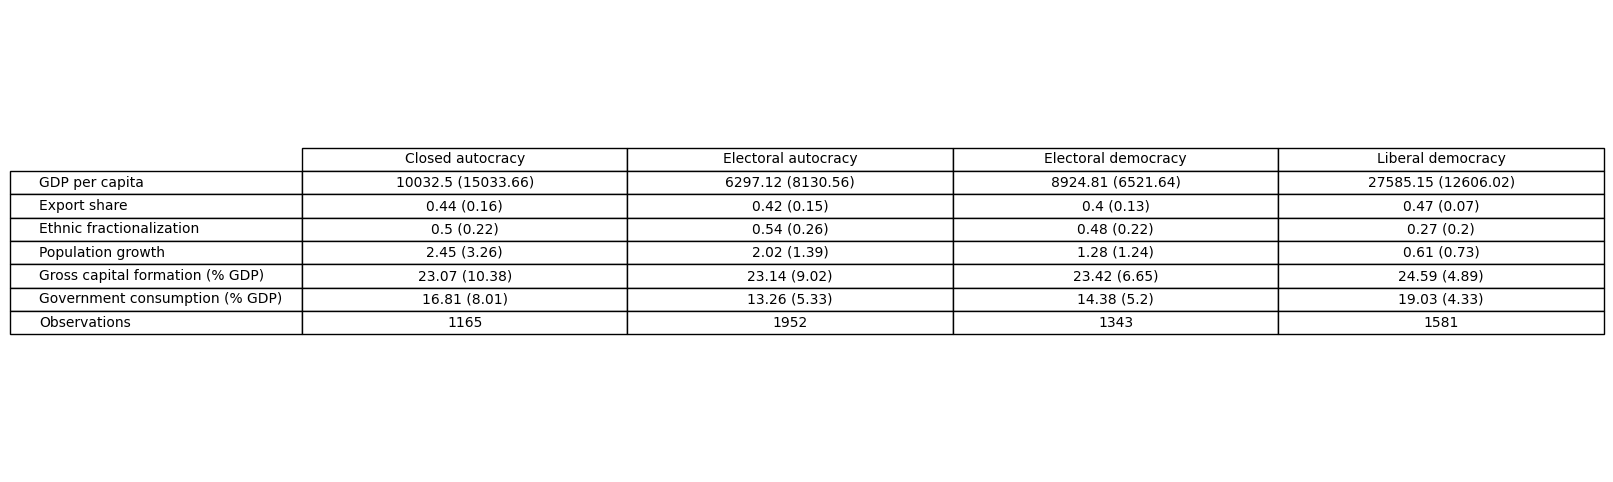

In [114]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    rowLabels=table.index,
    loc="center",
    cellLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.4)

plt.savefig("summary_statistics.png", dpi=300, bbox_inches="tight")
plt.show()




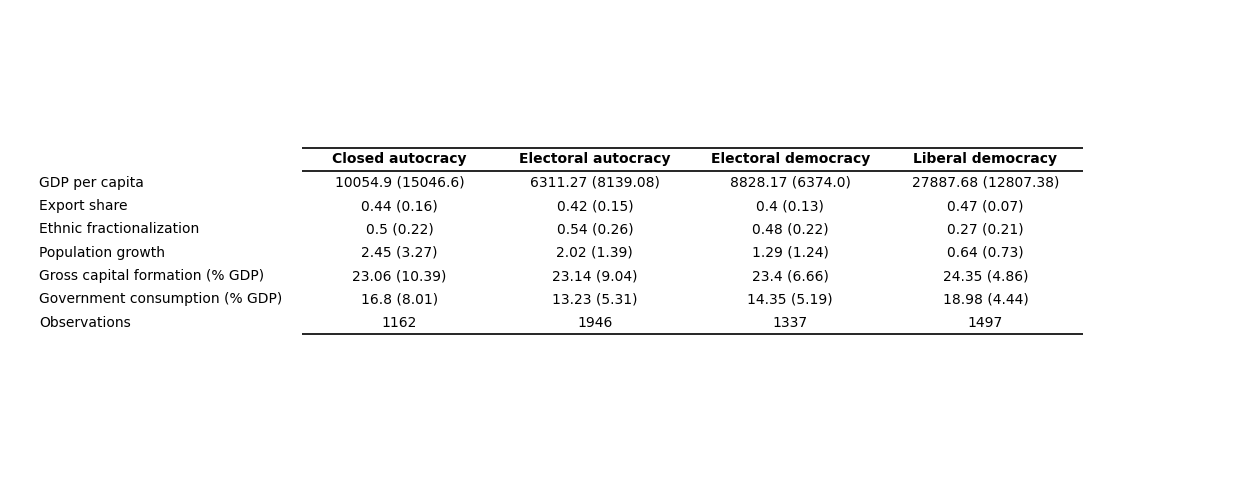

In [274]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    rowLabels=table.index,
    loc="center",
    cellLoc="center",
    colWidths=[0.15] * len(table.columns))


# -----------------------------
# Basic font & scale
# -----------------------------
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.4)

# -----------------------------
# Remove ALL borders first
# -----------------------------
for cell in tbl.get_celld().values():
    cell.set_linewidth(0)

# -----------------------------
# Identify table dimensions
# -----------------------------
n_rows = len(table.index)
n_cols = len(table.columns)

# -----------------------------
# Top rule (above column labels)
# -----------------------------
for c in range(n_cols):
    cell = tbl[(0, c)]
    cell.visible_edges = "T"
    cell.set_linewidth(1.2)

# -----------------------------
# Double rule under column labels
# -----------------------------
for c in range(n_cols):
    cell = tbl[(1, c)]
    cell.visible_edges = "T"
    cell.set_linewidth(1.2)

# -----------------------------
# Bottom rule (end of table)
# -----------------------------
for c in range(n_cols):
    cell = tbl[(n_rows, c)]
    cell.visible_edges = "B"
    cell.set_linewidth(1.2)

# -----------------------------
# Optional: bold column headers
# -----------------------------
for c in range(n_cols):
    tbl[(0, c)].get_text().set_fontweight("bold")

# -----------------------------
# Save figure
# -----------------------------
plt.savefig("summary_statistics.png", dpi=300, bbox_inches="tight")
plt.show()


In [118]:
df_copy['country'].nunique()

138

In [119]:
# Estimating the Tansition_Rate_per_Country_Year
import pandas as pd
import matplotlib.pyplot as plt

# Sort by country and year
df_copy = training_df.sort_values(by=["country", "year"])

# Identify regime transitions
df_copy['transition'] = df_copy.groupby('country')['v2x_regime'].diff().ne(0).astype(int)

# Calculate transition rate per country-year for each region
transition_rate_per_region = df_copy.groupby('region_num')['transition'].mean()

# Your region names in the same order as region_num (1 to 8)
region_names = [
    "Asia (East)",
    "Asia (South and South-East)",
    "Eastern Europe",
    "Latin America",
    "Middle East",
    "Sub-Sahara Africa",
    "Western Europe",
    "Western Offshoots"
]

# Create a table with region names
transition_table = pd.DataFrame({
    'Region': region_names,
    'Transition_Rate_per_Country_Year': transition_rate_per_region.values
})

print("Transition Rates per Region:\n")
print(transition_table)

Transition Rates per Region:

                        Region  Transition_Rate_per_Country_Year
0                  Asia (East)                          0.055944
1  Asia (South and South-East)                          0.119005
2               Eastern Europe                          0.106095
3                Latin America                          0.097122
4                  Middle East                          0.062176
5            Sub-Sahara Africa                          0.097865
6               Western Europe                          0.040945
7            Western Offshoots                          0.032468


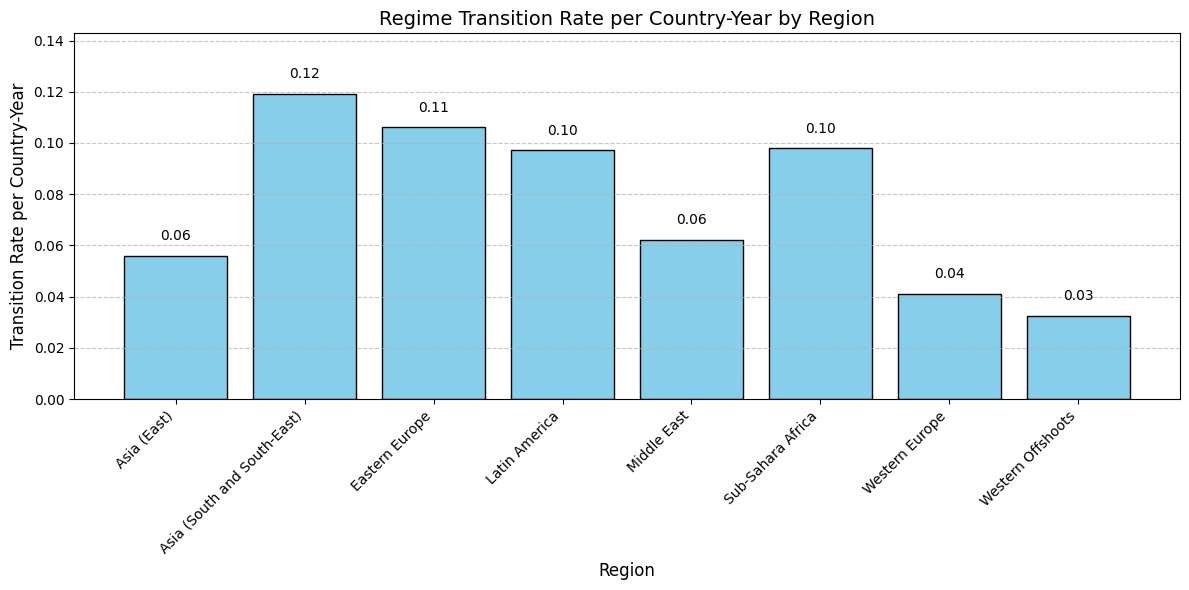

In [121]:
import matplotlib.pyplot as plt

# ---------------------------
# Visualization
# ---------------------------
plt.figure(figsize=(12,6))
bars = plt.bar(transition_table['Region'],
        transition_table['Transition_Rate_per_Country_Year'],
        color='skyblue', edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Region', fontsize=12)
plt.ylabel('Transition Rate per Country-Year', fontsize=12)
plt.title('Regime Transition Rate per Country-Year by Region', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(transition_table['Transition_Rate_per_Country_Year'])*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("transition_rates.png", dpi=300, bbox_inches="tight")
plt.show()



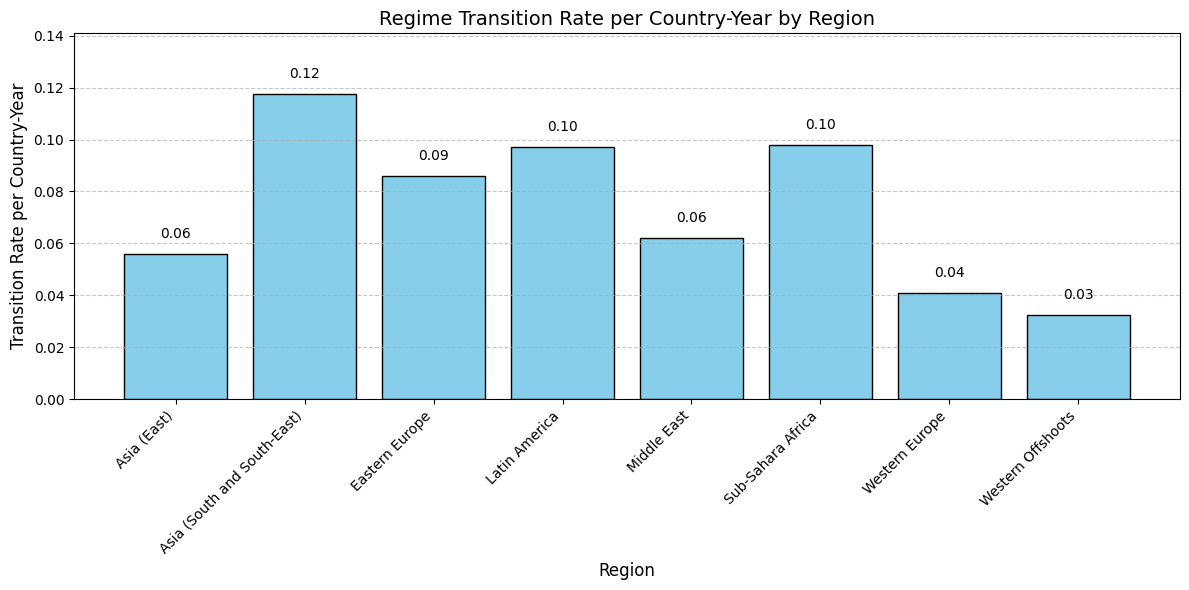

In [186]:
import matplotlib.pyplot as plt

# ---------------------------
# Visualization
# ---------------------------
plt.figure(figsize=(12,6))
bars = plt.bar(
    transition_table['Region'],
    transition_table['Transition_Rate_per_Country_Year'],
    color='skyblue',
    edgecolor='black'
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Region', fontsize=12)
plt.ylabel('Transition Rate per Country-Year', fontsize=12)
plt.title('Regime Transition Rate per Country-Year by Region', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(transition_table['Transition_Rate_per_Country_Year']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# ---------------------------
# Save as PNG
# ---------------------------
plt.savefig("transition_rates.png", dpi=300, bbox_inches="tight")

plt.show()


In [135]:
# Transition-year dummy:
# = 1 if regime changes compared to previous year within the same country
# = 0 otherwise
df_copy["transition_year_dummy"] = (
    df_copy
    .groupby("country")["v2x_regime"]
    .diff()
    .ne(0)
    .astype(int)
)


In [136]:
df_copy["transition_year_dummy"] = df_copy["transition_year_dummy"].fillna(0)


In [137]:
# How many transition years?
print(df_copy["transition_year_dummy"].value_counts())

# Look at a few countries manually
df_copy[["country", "year", "v2x_regime", "transition_year_dummy"]].head(15)

transition_year_dummy
0    4095
1     380
Name: count, dtype: int64


,country,year,v2x_regime,transition_year_dummy
0,AFG,2020,1.0,1
1,AFG,2021,1.0,0
2,AFG,2022,0.0,1
3,AGO,2002,0.0,1
4,AGO,2003,0.0,0
5,AGO,2004,0.0,0
6,AGO,2005,0.0,0
7,AGO,2006,0.0,0
8,AGO,2007,0.0,0
9,AGO,2008,0.0,0


In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Extract GATEs safely
# ---------------------------
gate_raw = results.get("gate")
gate_se_raw = results.get("gate_se")

# Convert to numpy and flatten
gate_array = np.array(gate_raw).flatten()
gate_se_array = np.array(gate_se_raw).flatten()

print("Extracted GATEs:", gate_array)
print("Extracted SEs:", gate_se_array)

Extracted GATEs: [ 0.00870564  0.16691134  0.61353056  0.1582057   0.60482492  0.44661922
 -0.02343466  0.12590407  0.54802309  0.14933873  0.57145775  0.42211902
 -0.15788307 -0.00895984  0.37382681  0.14892323  0.53170987  0.38278664
 -0.10153484  0.10862411  0.34065331  0.21015895  0.44218815  0.2320292
 -0.2585747  -0.10910421  0.35335873  0.1494705   0.61193343  0.46246294
 -0.07189024  0.11921945  0.65997516  0.19110969  0.7318654   0.54075571
 -0.06437445  0.09927638  0.44820484  0.16365083  0.51257929  0.34892846
 -0.27148019 -0.07230267  0.41595122  0.19917752  0.68743141  0.48825388]
Extracted SEs: [0.07899209 0.08692693 0.09791527 0.07455349 0.08711678 0.09437094
 0.07423451 0.06363543 0.07063049 0.0625874  0.06968774 0.05826737
 0.10882121 0.10876547 0.10555033 0.06350111 0.0578216  0.05771663
 0.05011392 0.04222451 0.03847823 0.04891458 0.0457198  0.03690265
 0.10988467 0.10156945 0.13104067 0.06714292 0.10659961 0.09800607
 0.05575918 0.06709899 0.09546235 0.06170478 0.09

In [139]:
region_names = [
    "Asia (East)",
    "Asia (South & South-East)",
    "Eastern Europe",
    "Latin America",
    "Middle East",
    "Sub-Saharan Africa",
    "Western Europe",
    "Western Offshoots"
]

# 48 GATEs = 8 regions × 6 subgroups
region_labels = np.repeat(region_names, len(gate_array) // len(region_names))

df_full = pd.DataFrame({
    "Region": region_labels,
    "GATE": gate_array,
    "SE": gate_se_array
})

# Aggregate to region-level GATEs
df_plot = df_full.groupby("Region").agg({
    "GATE": "mean",
    "SE": "mean"
}).reset_index()

df_plot = df_plot.sort_values("GATE")


# Sort for nicer visualization
df_plot = df_plot.sort_values("GATE")

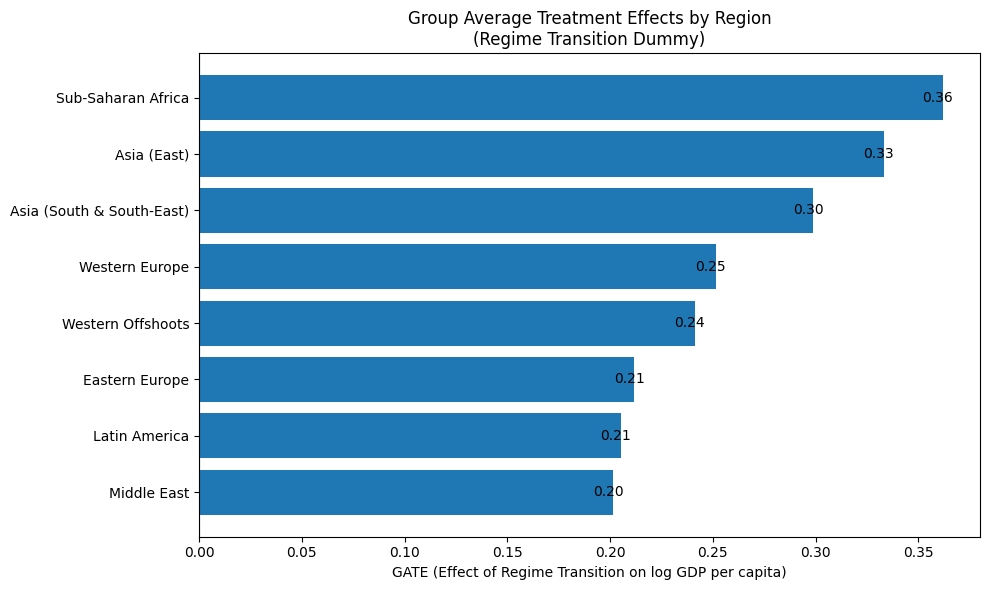

In [140]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_plot["Region"],
    df_plot["GATE"]
)

# Zero line
plt.axvline(0)

plt.xlabel("GATE (Effect of Regime Transition on log GDP per capita)")
plt.title("Group Average Treatment Effects by Region\n(Regime Transition Dummy)")

# Optional value labels
for i, v in enumerate(df_plot["GATE"]):
    plt.text(v - 0.01, i, f"{v:.2f}", va="center")

plt.tight_layout()
plt.show()

In [200]:
# Access the Group Average Treatment Effect (GATE)

gate = results.get("gate")
gate_se = results.get("gate_se")

print("GATE:\n", gate)
print("GATE standard errors:\n", gate_se)

GATE:
 [array([[[[ 0.00870564,  0.16691134,  0.61353056,  0.1582057 ,
           0.60482492,  0.44661922]]],


       [[[-0.02343466,  0.12590407,  0.54802309,  0.14933873,
           0.57145775,  0.42211902]]],


       [[[-0.15788307, -0.00895984,  0.37382681,  0.14892323,
           0.53170987,  0.38278664]]],


       [[[-0.10153484,  0.10862411,  0.34065331,  0.21015895,
           0.44218815,  0.2320292 ]]],


       [[[-0.2585747 , -0.10910421,  0.35335873,  0.1494705 ,
           0.61193343,  0.46246294]]],


       [[[-0.07189024,  0.11921945,  0.65997516,  0.19110969,
           0.7318654 ,  0.54075571]]],


       [[[-0.06437445,  0.09927638,  0.44820484,  0.16365083,
           0.51257929,  0.34892846]]],


       [[[-0.27148019, -0.07230267,  0.41595122,  0.19917752,
           0.68743141,  0.48825388]]]])]
GATE standard errors:
 [array([[[[0.07899209, 0.08692693, 0.09791527, 0.07455349, 0.08711678,
          0.09437094]]],


       [[[0.07423451, 0.06363543, 0.07063049, 0

In [205]:
gate_raw = results["gate"]

type(gate_raw)
len(gate_raw)

1

In [206]:
import numpy as np

gate_arr = np.asarray(gate_raw[0])
print(gate_arr.shape)


(8, 1, 1, 6)


In [207]:
gate_clean = gate_arr[:, 0, 0, :]


In [208]:
import pandas as pd

region_names = [
    "Asia (East)",
    "Asia (South and South-East)",
    "Eastern Europe",
    "Latin America",
    "Middle East",
    "Sub-Sahara Africa",
    "Western Europe",
    "Western Offshoots"
]

gate_df = pd.DataFrame(
    gate_clean,
    index=region_names,
    columns=[
        "Regime 1 → 2",
        "Regime 1 → 3",
        "Regime 1 → 4",
        "Regime 2 → 3",
        "Regime 2 → 4",
        "Regime 3 → 4"
    ]
)

gate_df


,Regime 1 → 2,Regime 1 → 3,Regime 1 → 4,Regime 2 → 3,Regime 2 → 4,Regime 3 → 4
Asia (East),0.008706,0.166911,0.613531,0.158206,0.604825,0.446619
Asia (South and South-East),-0.023435,0.125904,0.548023,0.149339,0.571458,0.422119
Eastern Europe,-0.157883,-0.008960,0.373827,0.148923,0.531710,0.382787
Latin America,-0.101535,0.108624,0.340653,0.210159,0.442188,0.232029
Middle East,-0.258575,-0.109104,0.353359,0.149470,0.611933,0.462463
Sub-Sahara Africa,-0.071890,0.119219,0.659975,0.191110,0.731865,0.540756
Western Europe,-0.064374,0.099276,0.448205,0.163651,0.512579,0.348928
Western Offshoots,-0.271480,-0.072303,0.415951,0.199178,0.687431,0.488254


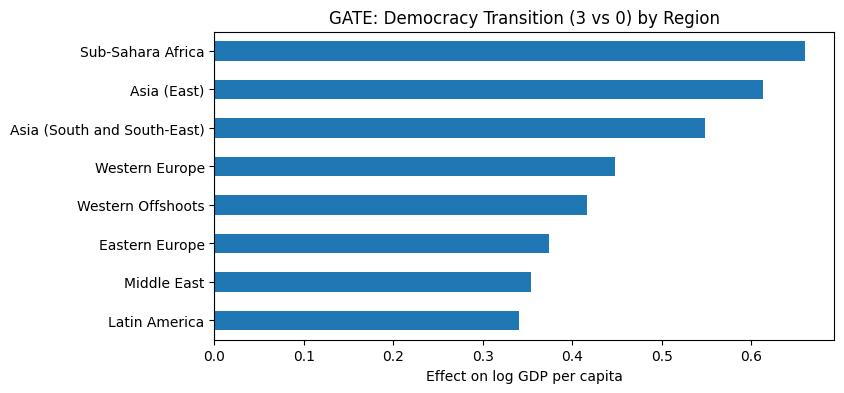

In [209]:
import matplotlib.pyplot as plt

effects = gate_df["Regime 1 → 4"]  # adjust column if needed

plt.figure(figsize=(8, 4))
effects.sort_values().plot(kind="barh")
plt.axvline(0)
plt.title("GATE: Democracy Transition (3 vs 0) by Region")
plt.xlabel("Effect on log GDP per capita")
plt.savefig("gate_effects_Regime 1 → 4.png", dpi=300, bbox_inches="tight")
plt.show()

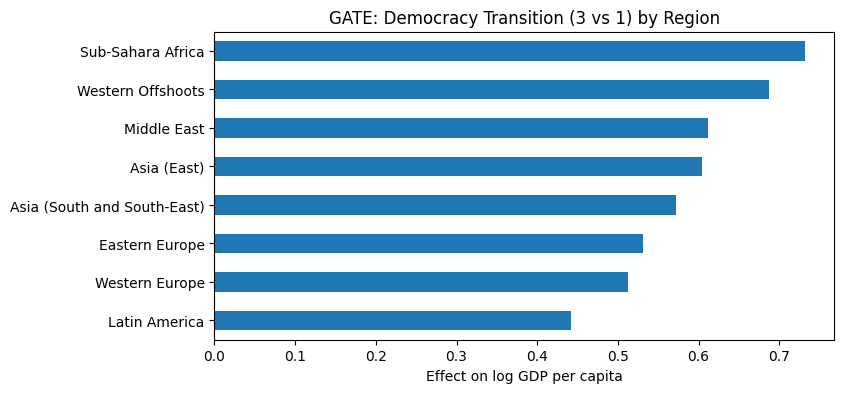

In [210]:
import matplotlib.pyplot as plt

effects = gate_df["Regime 2 → 4"]  # adjust column if needed

plt.figure(figsize=(8, 4))
effects.sort_values().plot(kind="barh")
plt.axvline(0)
plt.title("GATE: Democracy Transition (3 vs 1) by Region")
plt.xlabel("Effect on log GDP per capita")
plt.savefig("gate_effects_Regime 2 → 4.png", dpi=300, bbox_inches="tight")

plt.show()


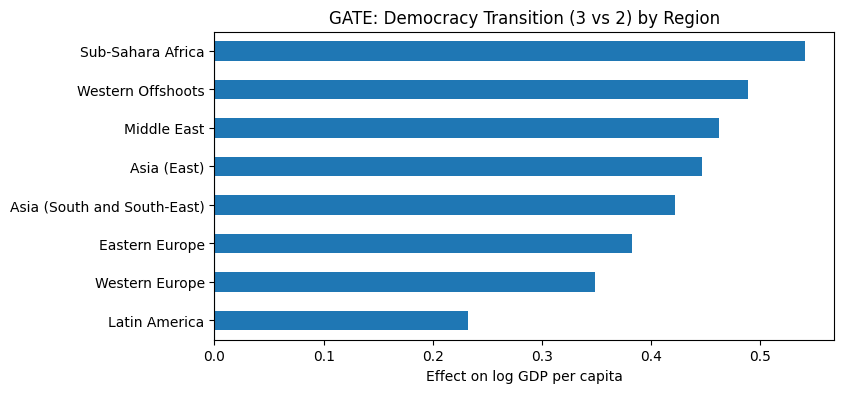

In [211]:
import matplotlib.pyplot as plt

effects = gate_df["Regime 3 → 4"]  # adjust column if needed

plt.figure(figsize=(8, 4))
effects.sort_values().plot(kind="barh")
plt.axvline(0)
plt.title("GATE: Democracy Transition (3 vs 2) by Region")
plt.xlabel("Effect on log GDP per capita")
plt.savefig("gate_effects_Regime 3 → 4.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
len(df_copy)

6041

In [15]:
#************************************#
# Data Interpolation - Linear Method #
#************************************#

import pandas as pd



df_copy_interpolated = df_copy.sort_values(["country", "year"])

# variables to interpolate
vars_to_interp = df_copy.columns.difference(["country", "year"])

df_copy_interpolated = (
    df_copy
    .groupby("country", group_keys=False)
    .apply(lambda x: x.assign(
        **{col: x[col].interpolate(method="linear", limit_direction="both")
           for col in vars_to_interp}
    ))
)

# Data Interpolation check
df_copy_interpolated[df_copy_interpolated["country"] == "GIN"]

# Save the final data Interpolated as csv

df_copy_interpolated.to_csv("df_copy_interpolated.csv", index=False)

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_5680/1368615941.py:18: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  **{col: x[col].interpolate(method="linear", limit_direction="both")
/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_5680/1368615941.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


In [35]:
df_copy

,country,year,log_gdppc,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),region,region_num
0,AFG,2020,7.564474,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,Asia (South and South-East),2
1,AFG,2021,7.303538,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,Asia (South and South-East),2
2,AFG,2022,7.213759,0.750797,1357.987823,0.0,1.410,0.126866,16.700000,21.845492,Asia (South and South-East),2
3,AGO,2002,7.833074,0.756100,2522.671861,0.0,3.435,0.761047,30.493173,19.130579,Sub-Sahara Africa,6
4,AGO,2003,7.905415,0.756100,2711.928311,0.0,3.550,0.706134,30.451111,21.854260,Sub-Sahara Africa,6
...,...,...,...,...,...,...,...,...,...,...,...,...
5937,ZWE,2018,7.549714,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,Sub-Sahara Africa,6
5938,ZWE,2019,7.469098,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,Sub-Sahara Africa,6
5939,ZWE,2020,7.368953,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,Sub-Sahara Africa,6
5940,ZWE,2021,7.430857,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,Sub-Sahara Africa,6


NameError: name 'sns' is not defined

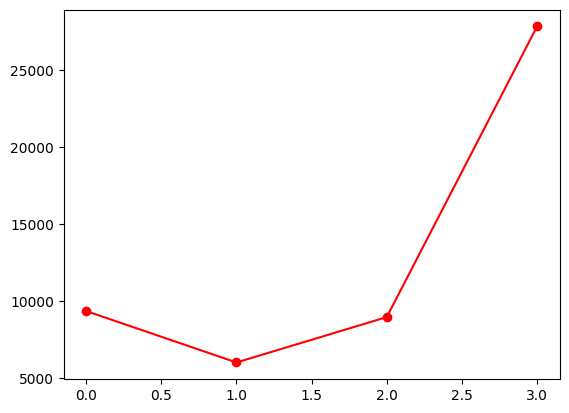

In [36]:
# Compute mean GDP per level
mean_gdp = df.groupby('v2x_regime')['gdppc'].mean().sort_index()

# Plot mean line
plt.plot(mean_gdp.index, mean_gdp.values, marker='o', color='red', label='Mean GDP')

# Overlay all points with jitter
sns.stripplot(x='v2x_regime', y='GDP_per_capita', data=df, jitter=True, alpha=0.5)
plt.xlabel('Democracy Level')
plt.ylabel('GDP per Capita')
plt.title('GDP per Capita Before and After Democratization')
plt.legend()
plt.show()

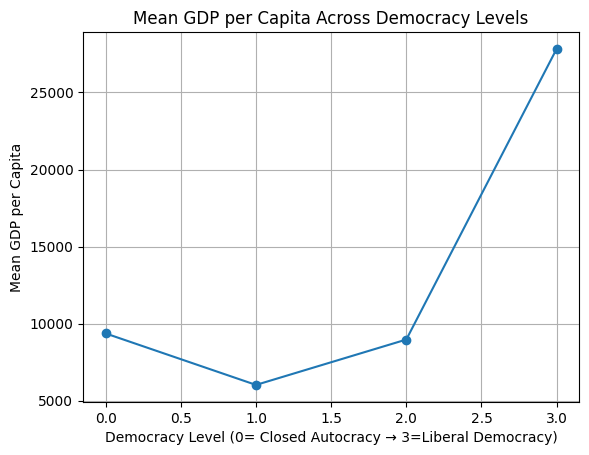

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute mean GDP per level
mean_gdp = df.groupby('v2x_regime')['gdppc'].mean().sort_index()

plt.plot(mean_gdp.index, mean_gdp.values, marker='o')
plt.xlabel('Democracy Level (0= Closed Autocracy → 3=Liberal Democracy)')
plt.ylabel('Mean GDP per Capita')
plt.title('Mean GDP per Capita Across Democracy Levels')
plt.grid(True)
plt.savefig("mean_gdp.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: List of boxplot statistics and `positions` values must have same the length

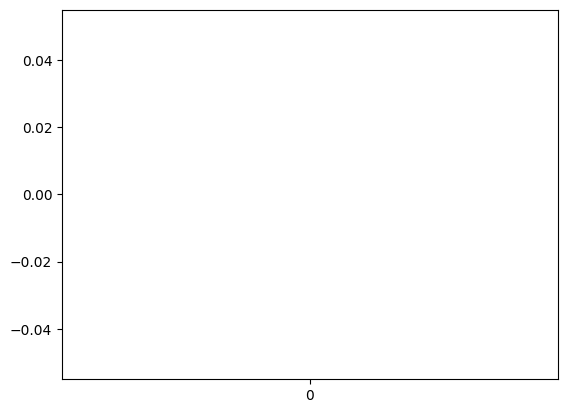

In [38]:
import seaborn as sns

sns.boxplot(x='v2x_regime', y='gdppc', data=df, order=[0,1,2,3])
plt.xlabel('Democracy Level')
plt.ylabel('GDP per Capita')
plt.title('GDP per Capita Before and After Democratization')
plt.show()